In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results/experiment_results.csv')
summary = pd.read_csv('results/experiment_summary.csv')
df.head()

,persona,model,day,took_trip,mode,distance_km,co2_avoided_kg,tokens_earned,engagement,streak_days,next_day_trip_probability
0,walker_biker,counterfactual,0,True,bike,2.71,0.488,2.44,0.5059,1,0.8550
1,walker_biker,counterfactual,1,True,bike,7.25,1.305,6.52,0.5210,2,0.8678
2,walker_biker,counterfactual,2,True,walk,1.66,0.299,1.49,0.5257,3,0.8719
3,walker_biker,counterfactual,3,True,bike,6.01,1.082,5.41,0.5422,4,0.8858
4,walker_biker,counterfactual,4,True,walk,5.12,0.922,4.61,0.5563,5,0.8979


In [8]:
summary.sort_values(['persona', 'avg_engagement_last_14d'], ascending=[True, False])

,persona,model,total_tokens,total_co2_avoided_kg,trip_days,final_engagement,avg_engagement_last_14d,max_streak
4,carpooler,matched_trip,209.11,31.745,39,0.0000,0.030433,4
2,carpooler,hybrid_waterfall,261.42,42.580,46,0.0022,0.006740,4
0,carpooler,counterfactual,194.14,38.821,48,0.0000,0.003780,4
3,carpooler,hybrid_weighted,192.27,28.995,48,0.0000,0.003513,4
1,carpooler,historical,68.46,2.441,43,0.0000,0.001100,4
5,casual_inconsistent,counterfactual,49.94,9.988,18,0.0000,0.001320,2
8,casual_inconsistent,hybrid_weighted,38.65,5.070,18,0.0000,0.001167,2
7,casual_inconsistent,hybrid_waterfall,32.36,2.706,18,0.0000,0.001100,2
9,casual_inconsistent,matched_trip,28.75,2.220,18,0.0000,0.001100,1
6,casual_inconsistent,historical,22.47,4.258,18,0.0000,0.000000,1


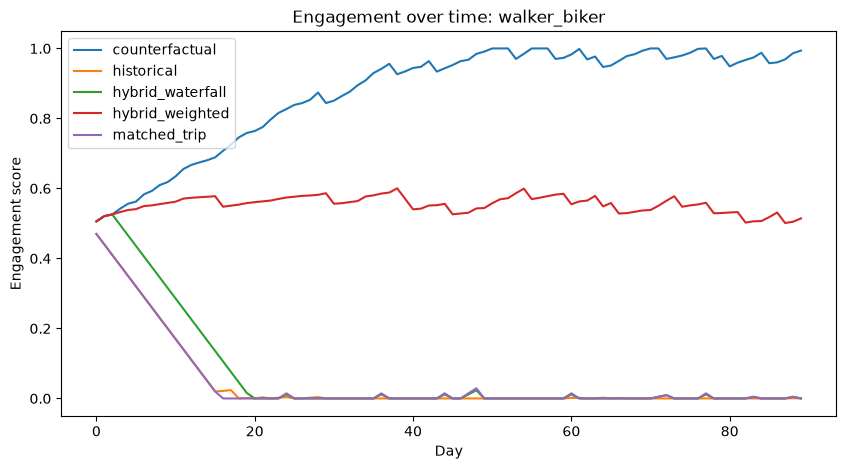

In [9]:
PERSONA = 'walker_biker'

fig, ax = plt.subplots(figsize=(10, 5))
for model_name, group in df[df['persona'] == PERSONA].groupby('model'):
    ax.plot(group['day'], group['engagement'], label=model_name)
ax.set_xlabel('Day')
ax.set_ylabel('Engagement score')
ax.set_title(f'Engagement over time: {PERSONA}')
ax.legend()
plt.show()

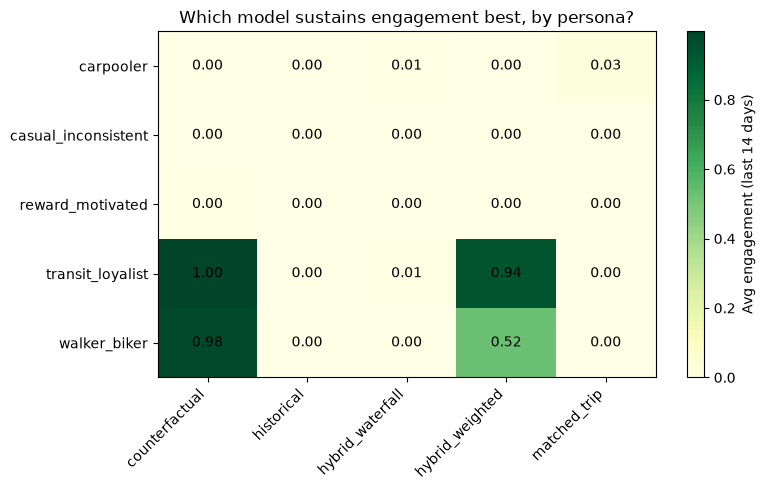

In [10]:
pivot = summary.pivot(index='persona', columns='model', values='avg_engagement_last_14d')
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, label='Avg engagement (last 14 days)')
plt.title('Which model sustains engagement best, by persona?')
plt.tight_layout()
plt.show()

In [11]:
model_totals = summary.groupby('model')[['total_tokens', 'total_co2_avoided_kg']].sum()
model_totals['tokens_per_kg_co2'] = model_totals['total_tokens'] / model_totals['total_co2_avoided_kg']
model_totals

,total_tokens,total_co2_avoided_kg,tokens_per_kg_co2
model,,,
counterfactual,1228.18,245.635,5.000020
historical,131.74,6.938,18.988181
hybrid_waterfall,517.39,82.466,6.273980
hybrid_weighted,614.41,103.086,5.960169
matched_trip,386.79,57.944,6.675238


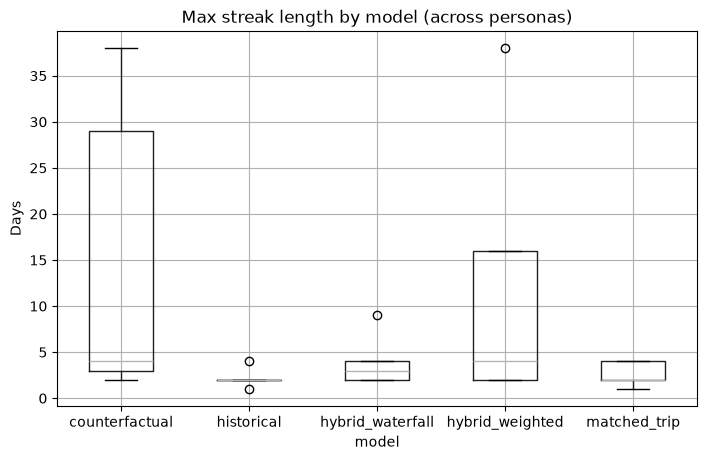

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
summary.boxplot(column='max_streak', by='model', ax=ax)
plt.title('Max streak length by model (across personas)')
plt.suptitle('')
plt.ylabel('Days')
plt.show()